# 🚗 Car Position and Velocity Estimation using Data Assimilation

In this problem, we simulate the motion of a car in one dimension. The state of the system consists of two variables:

- **Position** \([m]\)
- **Velocity** \([m/s]\)

The system evolves in time according to a simple kinematic model, assuming constant velocity. However, only **noisy position observations** are available at discrete time steps.

The goal is to use different data assimilation methods (e.g., Nudging, Kalman Filter, Ensemble Kalman Filter) to estimate the true position and velocity of the car more accurately by combining:

- A **model prediction** of the system's behavior, and  
- **Partial and noisy observations** (only the position)

This setup allows us to compare the effectiveness of various assimilation methods in filtering out noise and reconstructing unobserved state variables (like velocity) from incomplete data.


## Car Position Estimation with Nudging

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

np.random.seed(42)

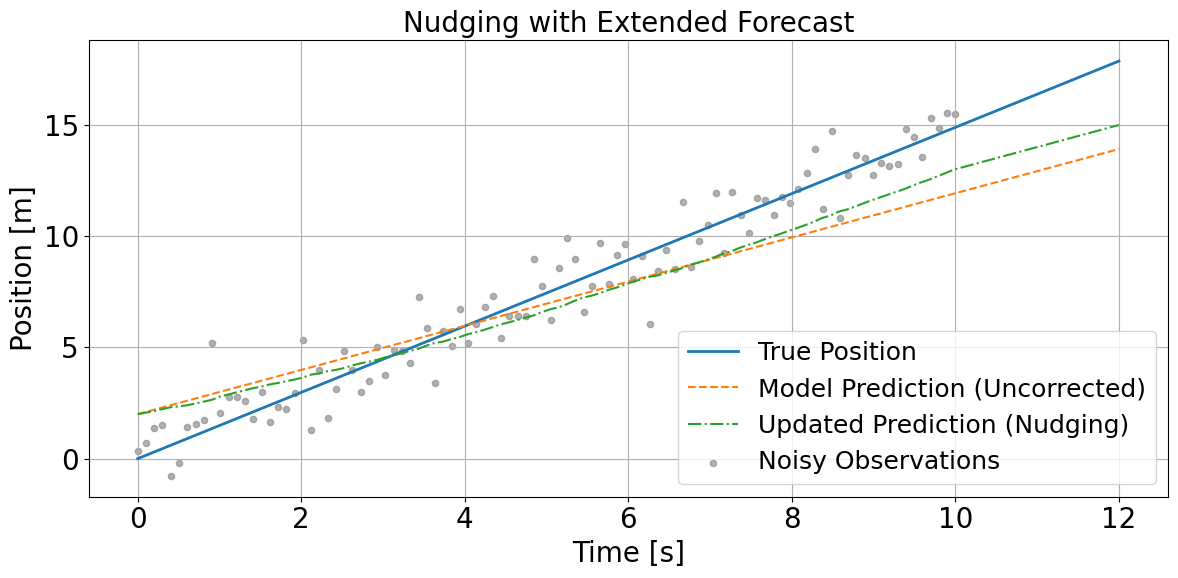

In [27]:
# Número de pasos adicionales
extra_steps = 20
total_steps = steps + extra_steps
time_extended = np.linspace(0, T + extra_steps * dt, total_steps)

# Extender estado verdadero
x_true_ext = np.zeros((total_steps, 2))
x_true_ext[:steps] = x_true
for k in range(steps, total_steps):
    x_true_ext[k, 0] = x_true_ext[k-1, 0] + dt * x_true_ext[k-1, 1]
    x_true_ext[k, 1] = x_true_ext[k-1, 1]

# Extender modelo no corregido
x_model_ext = np.zeros((total_steps, 2))
x_model_ext[:steps] = x_model
for k in range(steps, total_steps):
    x_model_ext[k, 0] = x_model_ext[k-1, 0] + dt * x_model_ext[k-1, 1]
    x_model_ext[k, 1] = x_model_ext[k-1, 1]

# Extender nudging sin nuevas observaciones
x_adj_ext = np.zeros((total_steps, 2))
x_adj_ext[:steps] = x_adjusted
for k in range(steps, total_steps):
    dx = x_adj_ext[k-1, 1]  # sin nudging posterior a la observación
    x_adj_ext[k, 0] = x_adj_ext[k-1, 0] + dt * dx
    x_adj_ext[k, 1] = x_adj_ext[k-1, 1]

# Plot extendido
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_ext[:, 0], label='True Position', linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time_extended, x_adj_ext[:, 0], label='Updated Prediction (Nudging)', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)

plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Nudging with Extended Forecast')
plt.legend(loc='lower right', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.show()


# Alpha analysis

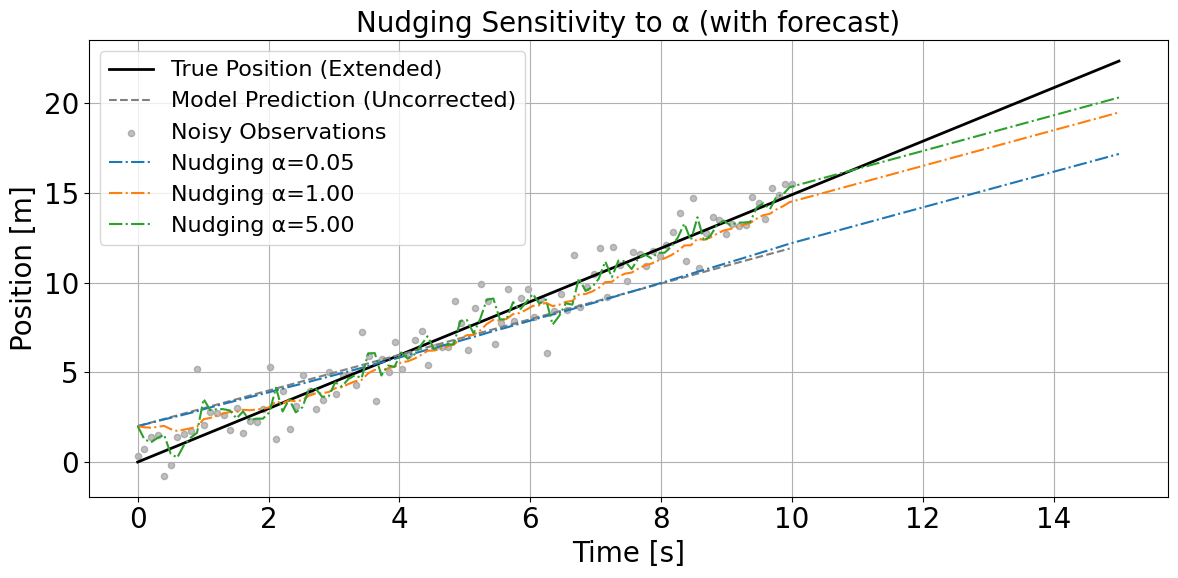

In [28]:
# Parámetros
extra_steps = 50  # pasos adicionales tras la asimilación
total_steps = steps + extra_steps
time_ext = np.linspace(0, T + dt * extra_steps, total_steps)

alphas = [0.05, 1.0, 5.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))

plt.figure(figsize=(12, 6))
plt.plot(time_ext, np.concatenate([x_true[:, 0], [x_true[-1, 0] + (k+1)*dt*v_true for k in range(extra_steps)]]),
         label='True Position (Extended)', color='black', linewidth=2)
plt.plot(time_ext[:steps], x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='gray')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.5)

for alpha, color in zip(alphas, colors):
    x_adj = np.zeros((total_steps, 2))
    x_adj[0] = x_model[0]
    for k in range(1, steps):
        dx = x_adj[k-1, 1] + alpha * (y_obs[k-1] - x_adj[k-1, 0])
        x_adj[k, 0] = x_adj[k-1, 0] + dt * dx
        x_adj[k, 1] = x_adj[k-1, 1]
    for k in range(steps, total_steps):
        # Solo forecast sin observaciones
        dx = x_adj[k-1, 1]
        x_adj[k, 0] = x_adj[k-1, 0] + dt * dx
        x_adj[k, 1] = x_adj[k-1, 1]

    plt.plot(time_ext, x_adj[:, 0], label=f'Nudging α={alpha:.2f}', linestyle='-.')

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Nudging Sensitivity to α (with forecast)', fontsize=20)
plt.legend(loc='upper left', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


## Car Position Estimation with Kalman Filter

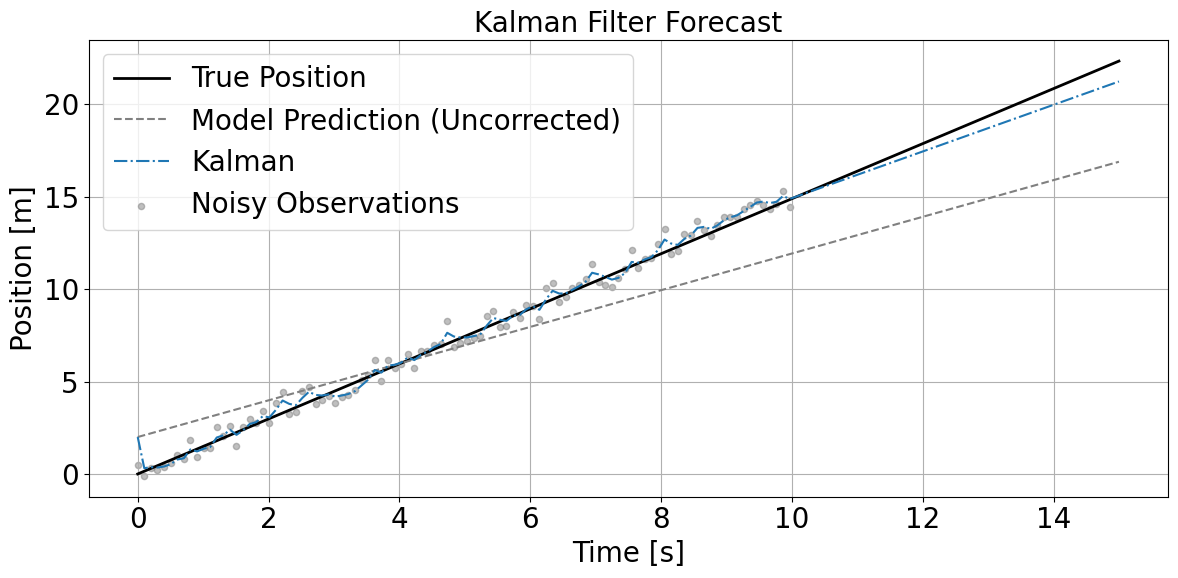

In [32]:
# Configuración de texto
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})

# Parámetros base
dt = 0.1
T = 10
steps = int(T / dt)
extra_steps = 50  # Pasos adicionales sin asimilación
total_steps = steps + extra_steps
time = np.linspace(0, T + extra_steps * dt, total_steps)
v_true = 1.5
pos_noise_std = 0.5

# Estado verdadero
x_true = np.zeros((total_steps, 2))
x_true[0] = [0, v_true]
for k in range(1, total_steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

# Observaciones (solo hasta el final del intervalo de asimilación)
y_obs = x_true[:steps, 0] + np.random.normal(0, pos_noise_std, steps)

# Modelo base (sin corrección)
x_model = np.zeros((total_steps, 2))
x_model[0] = [2.0, 1.0]
for k in range(1, total_steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

# Valor único de Q
Q_val = 0.05
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.array([[Q_val, 0], [0, Q_val]])
R = np.array([[pos_noise_std**2]])
I = np.eye(2)

x_kf = np.zeros((total_steps, 2))
x_kf[0] = [2.0, 1.0]
P = np.eye(2)

for k in range(1, total_steps):
    x_pred = F @ x_kf[k-1]
    P_pred = F @ P @ F.T + Q
    if k < steps:
        y = y_obs[k] - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x_kf[k] = x_pred + K @ y
        P = (I - K @ H) @ P_pred
    else:
        x_kf[k] = x_pred  # Forecast sin actualización

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='gray')
plt.plot(time, x_kf[:, 0], label=f'Kalman', linestyle='-.')

plt.scatter(time[:steps], y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.5)

plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Kalman Filter Forecast'.format(Q_val))
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


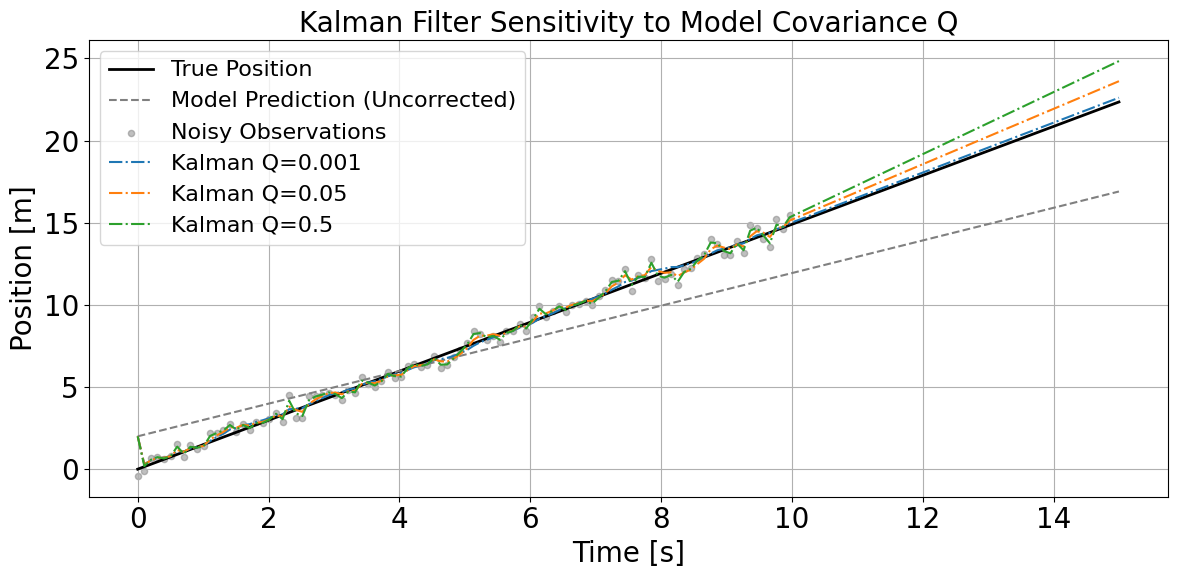

In [29]:
# Parámetros base
dt = 0.1
T = 10
steps = int(T / dt)
extra_steps = 50  # Extensión del forecast
total_steps = steps + extra_steps
time = np.linspace(0, T + extra_steps * dt, total_steps)
v_true = 1.5
pos_noise_std = 0.5

# Estado verdadero
x_true = np.zeros((total_steps, 2))
x_true[0] = [0, v_true]
for k in range(1, total_steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

# Observaciones
y_obs = x_true[:steps, 0] + np.random.normal(0, pos_noise_std, steps)

# Modelo base (sin corrección)
x_model = np.zeros((total_steps, 2))
x_model[0] = [2.0, 1.0]
for k in range(1, total_steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

# Valores de Q a comparar
Q_values = [0.001, 0.05, 0.5]
colors = ['tab:green', 'tab:orange', 'tab:blue']

plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='gray')
plt.scatter(time[:steps], y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.5)

for Q_val, color in zip(Q_values, colors):
    F = np.array([[1, dt], [0, 1]])
    H = np.array([[1, 0]])
    Q = np.array([[Q_val, 0], [0, Q_val]])
    R = np.array([[pos_noise_std**2]])
    I = np.eye(2)

    x_kf = np.zeros((total_steps, 2))
    x_kf[0] = [2.0, 1.0]
    P = np.eye(2)

    for k in range(1, total_steps):
        x_pred = F @ x_kf[k-1]
        P_pred = F @ P @ F.T + Q
        if k < steps:
            y = y_obs[k] - H @ x_pred
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)
            x_kf[k] = x_pred + K @ y
            P = (I - K @ H) @ P_pred
        else:
            x_kf[k] = x_pred  # Solo forecast

    plt.plot(time, x_kf[:, 0], label=f'Kalman Q={Q_val}', linestyle='-.')

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Kalman Filter Sensitivity to Model Covariance Q', fontsize=20)
plt.legend(fontsize=16, loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


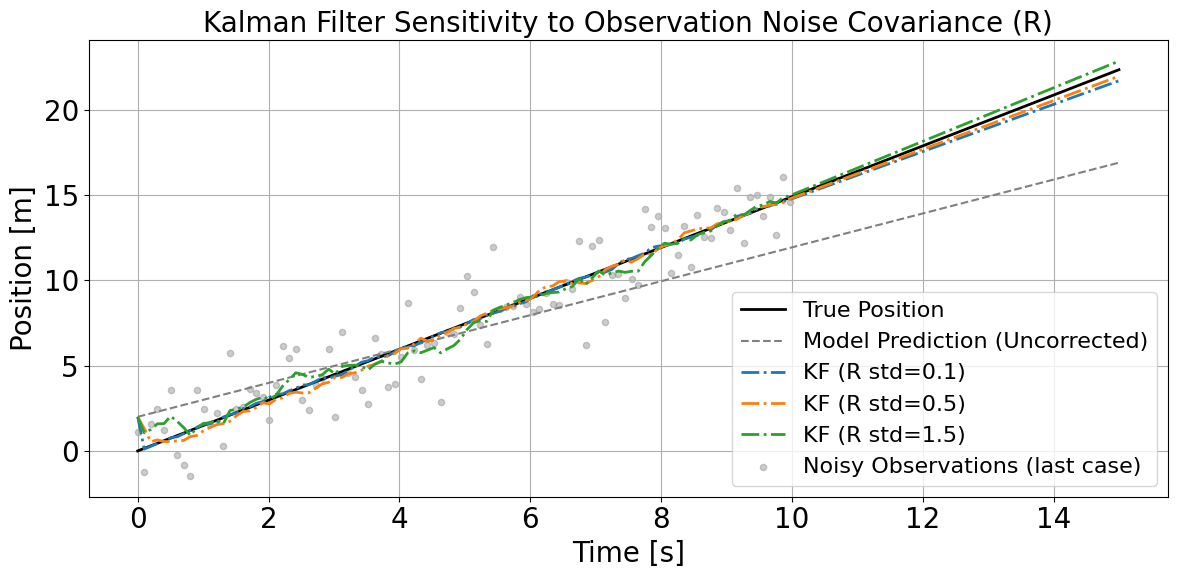

In [30]:
# Parámetros base
dt = 0.1
T = 10
extra_T = 5  # tiempo adicional
steps = int(T / dt)
extra_steps = int(extra_T / dt)
total_steps = steps + extra_steps
time = np.linspace(0, T + extra_T, total_steps)
v_true = 1.5

# Estado verdadero extendido
x_true = np.zeros((total_steps, 2))
x_true[0] = [0, v_true]
for k in range(1, total_steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

# Modelo sin corrección
x_model = np.zeros((total_steps, 2))
x_model[0] = [2.0, 1.0]
for k in range(1, total_steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

# Niveles de ruido
obs_std_values = [0.1, 0.5, 1.5]
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='gray')

for std, color in zip(obs_std_values, colors):
    y_obs = x_true[:steps, 0] + np.random.normal(0, std, steps)

    # Kalman filter
    F = np.array([[1, dt], [0, 1]])
    H = np.array([[1, 0]])
    Q = np.array([[0.01, 0], [0, 0.01]])
    R = np.array([[std**2]])
    I = np.eye(2)

    x_kf = np.zeros((total_steps, 2))
    x_kf[0] = [2.0, 1.0]
    P = np.eye(2)

    for k in range(1, total_steps):
        x_pred = F @ x_kf[k-1]
        P_pred = F @ P @ F.T + Q

        if k < steps:
            y = y_obs[k] - H @ x_pred
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)
            x_kf[k] = x_pred + K @ y
            P = (I - K @ H) @ P_pred
        else:
            x_kf[k] = x_pred
            P = P_pred

    plt.plot(time, x_kf[:, 0], linestyle='-.', linewidth=2, label=f'KF (R std={std})', color=color)

# Observaciones del último caso
plt.scatter(time[:steps], y_obs, label='Noisy Observations (last case)', color='gray', s=20, alpha=0.4)

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Kalman Filter Sensitivity to Observation Noise Covariance (R)', fontsize=20)
plt.legend(fontsize=16, loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


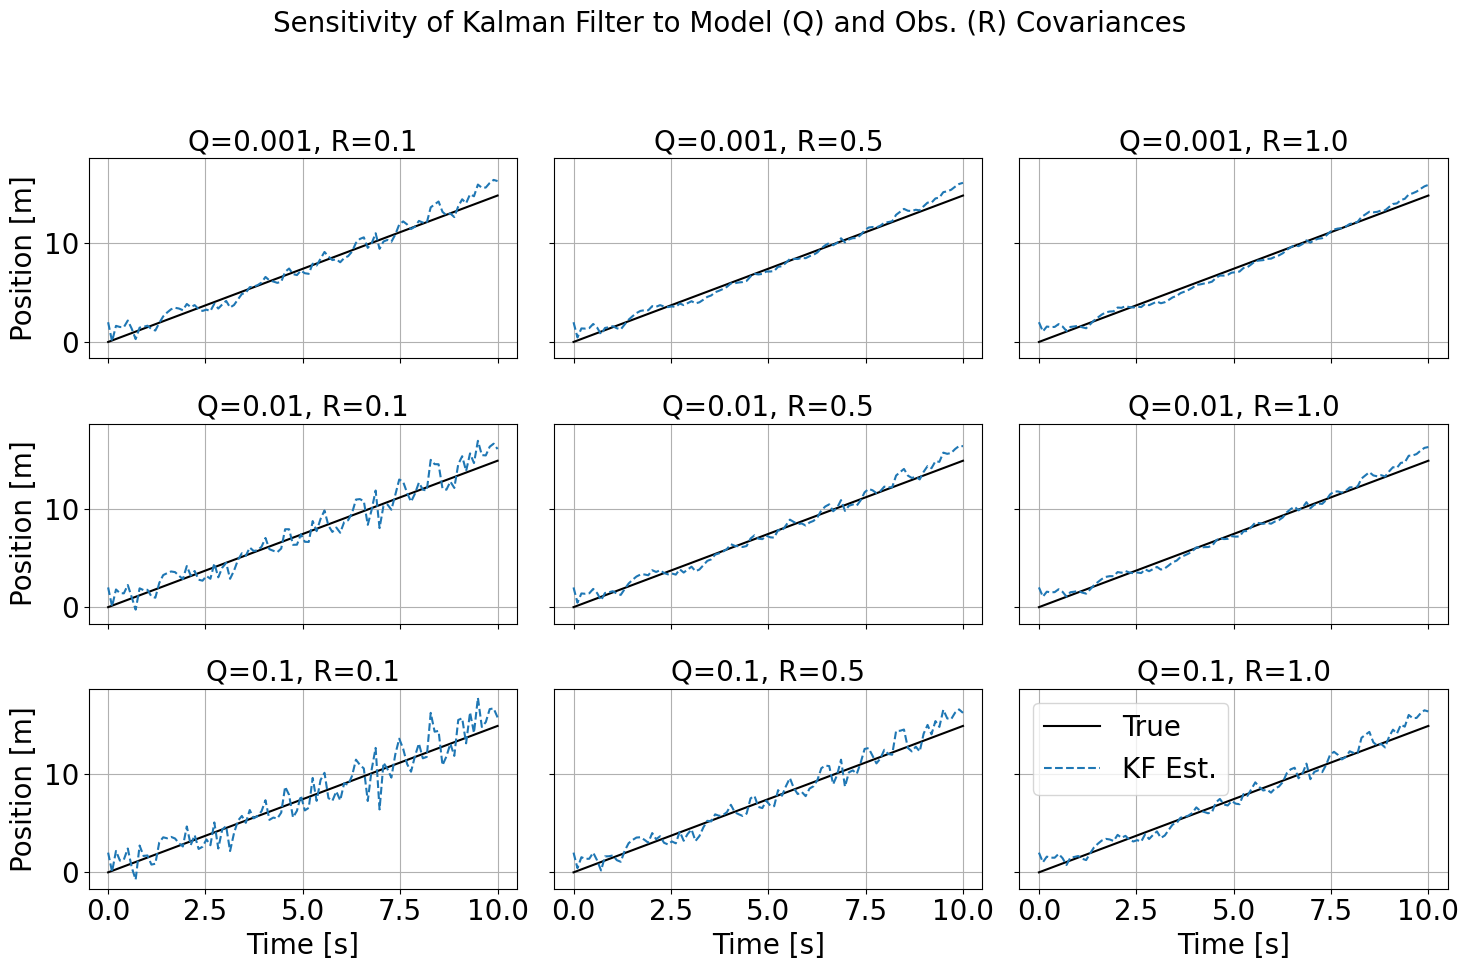

In [39]:
model_noise_levels = [0.001, 0.01, 0.1]
obs_noise_levels = [0.1, 0.5, 1.0]

fig, axs = plt.subplots(len(model_noise_levels), len(obs_noise_levels), figsize=(15, 10), sharex=True, sharey=True)

for i, q in enumerate(model_noise_levels):
    for j, r in enumerate(obs_noise_levels):
        Q = np.array([[q, 0], [0, q]])
        R = np.array([[r**2]])
        x_kf = np.zeros((steps, 2))
        x_kf[0] = [2.0, 1.0]
        P = np.eye(2)

        for k in range(1, steps):
            x_pred = F @ x_kf[k-1]
            P_pred = F @ P @ F.T + Q
            y = y_obs[k] - H @ x_pred
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)
            x_kf[k] = x_pred + K @ y
            P = (I - K @ H) @ P_pred

        ax = axs[i, j]
        ax.plot(time, x_true[:, 0], label='True', color='black')
        ax.plot(time, x_kf[:, 0], label='KF Est.', linestyle='--')
        ax.set_title(f'Q={q}, R={r}')
        if i == len(model_noise_levels)-1: ax.set_xlabel('Time [s]')
        if j == 0: ax.set_ylabel('Position [m]')
        ax.grid(True)

fig.suptitle('Sensitivity of Kalman Filter to Model (Q) and Obs. (R) Covariances', fontsize=20)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.legend()
plt.show()


## Car Position Estimation with Ensamble Kalman Filter

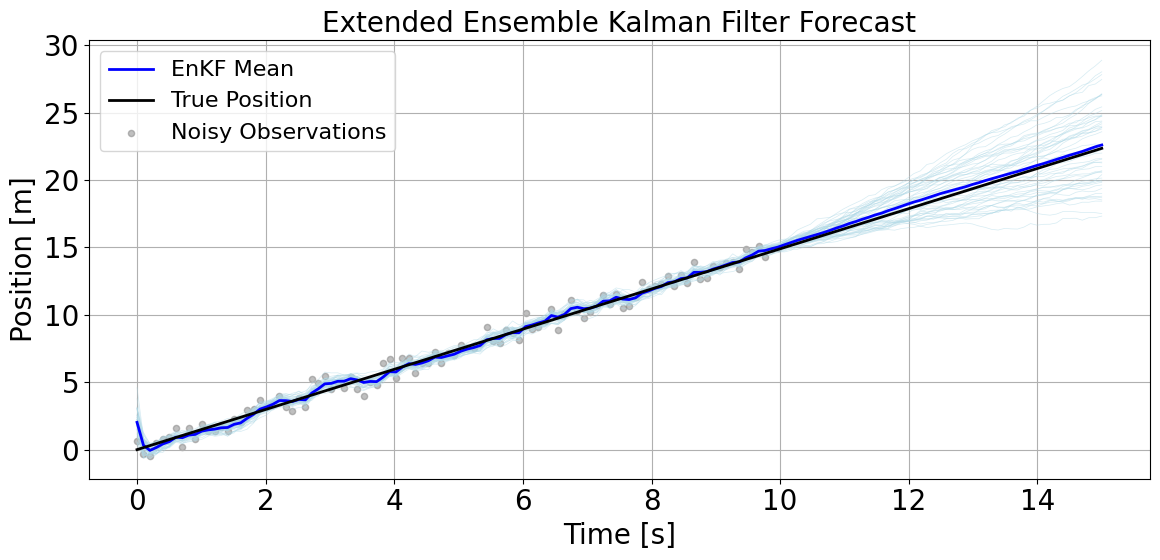

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
dt = 0.1
T = 10
extra_steps = 50  # pasos adicionales tras la asimilación
steps = int(T / dt)
total_steps = steps + extra_steps
time = np.linspace(0, T + extra_steps * dt, total_steps)
v_true = 1.5
pos_noise_std = 0.5
N = 50  # tamaño del ensemble

# Estado verdadero extendido
x_true = np.zeros((total_steps, 2))
x_true[0] = [0, v_true]
for k in range(1, total_steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

# Observaciones (solo durante asimilación)
y_obs = x_true[:steps, 0] + np.random.normal(0, pos_noise_std, steps)

# Modelo
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.array([[0.01, 0], [0, 0.01]])
R = np.array([[pos_noise_std**2]])

# Inicializar ensemble
x_ens = np.zeros((total_steps, N, 2))
x_ens[0, :, 0] = 2.0 + np.random.normal(0, 1.0, N)
x_ens[0, :, 1] = 1.0 + np.random.normal(0, 0.5, N)

x_enkf_mean = np.zeros((total_steps, 2))
x_enkf_mean[0] = np.mean(x_ens[0], axis=0)

# EnKF loop con forecast extendido
for k in range(1, total_steps):
    # Predicción
    for i in range(N):
        noise = np.random.multivariate_normal([0, 0], Q)
        x_ens[k, i] = F @ x_ens[k-1, i] + noise

    if k < steps:
        # Estadísticos
        x_mean = np.mean(x_ens[k], axis=0)
        X_prime = x_ens[k] - x_mean
        P_f = (X_prime.T @ X_prime) / (N - 1)

        # Observaciones perturbadas
        y_perturbed = y_obs[k] + np.random.normal(0, pos_noise_std, N)

        # Actualización
        for i in range(N):
            Hx = H @ x_ens[k, i]
            S = H @ P_f @ H.T + R
            K = P_f @ H.T @ np.linalg.inv(S)
            innovation = y_perturbed[i] - Hx
            x_ens[k, i] += (K @ innovation).flatten()

    x_enkf_mean[k] = np.mean(x_ens[k], axis=0)

# Gráfico
plt.figure(figsize=(12, 6))

# Todos los miembros del ensemble
for i in range(N):
    plt.plot(time, x_ens[:, i, 0], color='lightblue', linewidth=0.5, alpha=0.5)

# Resultados
plt.plot(time, x_enkf_mean[:, 0], label='EnKF Mean', color='blue', linewidth=2)
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.scatter(time[:steps], y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.5)

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Extended Ensemble Kalman Filter Forecast', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


## 3D-Var

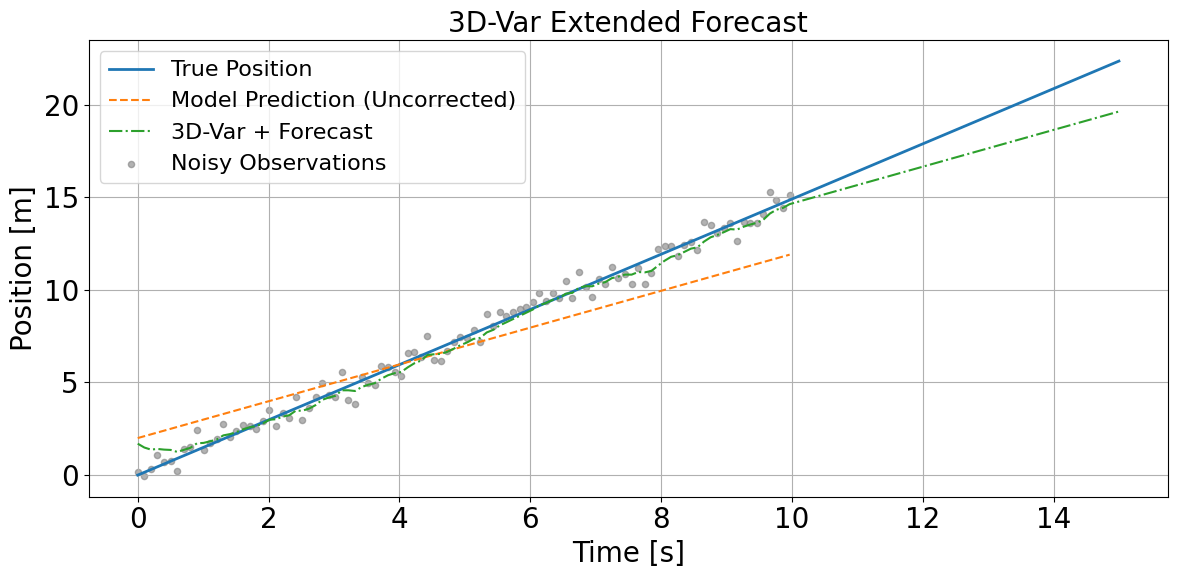

In [33]:
# Parámetros base
dt = 0.1
T = 10
steps = int(T / dt)
extra_steps = 50
total_steps = steps + extra_steps
time_extended = np.linspace(0, T + extra_steps * dt, total_steps)
v_true = 1.5
pos_noise_std = 0.5

# Estado verdadero extendido
x_true_extended = np.zeros((total_steps, 2))
x_true_extended[0] = [0, v_true]
for k in range(1, total_steps):
    x_true_extended[k, 0] = x_true_extended[k-1, 0] + dt * x_true_extended[k-1, 1]
    x_true_extended[k, 1] = x_true_extended[k-1, 1]

# Observaciones hasta el tiempo final T (no se observa después de la asimilación)
y_obs = x_true_extended[:steps, 0] + np.random.normal(0, pos_noise_std, steps)

# Predicción del modelo sin corrección
x_model = np.zeros((steps, 2))
x_model[0] = [2.0, 1.0]
for k in range(1, steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

# Matrices del modelo
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
B = np.diag([0.05, 0.05])
R = np.array([[pos_noise_std**2]])

# Ganancia de Kalman (constante en 3D-Var lineal)
K_3dvar = B @ H.T @ np.linalg.inv(H @ B @ H.T + R)

# Corrección + predicción extendida desde x^a
x_3dvar_extended = np.zeros((total_steps, 2))
x_3dvar_extended[0] = x_model[0] + (K_3dvar @ (y_obs[0] - H @ x_model[0])).flatten()

for k in range(1, steps):
    x_forecast = F @ x_3dvar_extended[k-1]
    innovation = y_obs[k] - H @ x_forecast
    x_3dvar_extended[k] = x_forecast + (K_3dvar @ innovation).flatten()

# Forecast extendido sin observaciones
for k in range(steps, total_steps):
    x_3dvar_extended[k] = F @ x_3dvar_extended[k-1]

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_extended[:, 0], label='True Position', linewidth=2)
plt.plot(time_extended[:steps], x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time_extended, x_3dvar_extended[:, 0], label='3D-Var + Forecast', linestyle='-.')
plt.scatter(time_extended[:steps], y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
#plt.axvline(x=time_extended[steps-1], color='red', linestyle=':', label='End of assimilation')
plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('3D-Var Extended Forecast', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


## 4D-Var

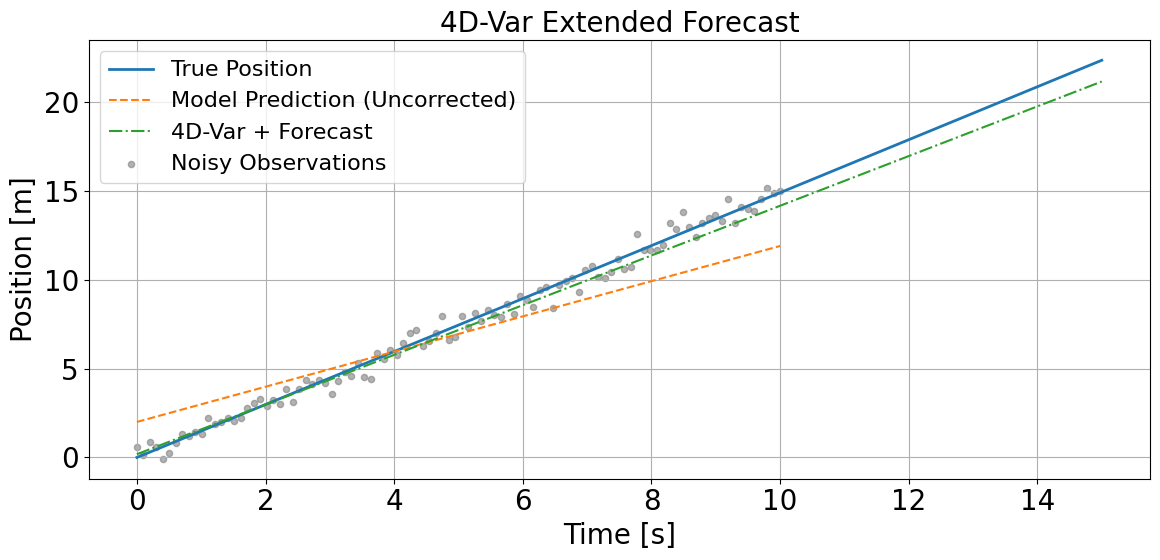

In [56]:
# Parámetros
dt = 0.1
T = 10
steps = int(T / dt)
extra_steps = 50  # Número de pasos adicionales tras la asimilación

# Covarianzas
B = np.diag([1.0, 1.0])
R = np.array([[pos_noise_std**2]])
H = np.array([[1, 0]])

# Modelo lineal
F = np.array([[1, dt], [0, 1]])
def model_propagate(x0, steps_total, F):
    traj = np.zeros((steps_total, 2))
    traj[0] = x0
    for k in range(1, steps_total):
        traj[k] = F @ traj[k-1]
    return traj

# Función de coste 4D-Var
def J(x0, window):
    x0 = np.array(x0)
    traj = model_propagate(x0, window, F)
    innov = y_obs[:window] - traj[:, 0]
    obs_term = np.sum((innov**2) / R[0, 0])
    back_term = (x0 - x_model[0]).T @ np.linalg.inv(B) @ (x0 - x_model[0])
    return 0.5 * (obs_term + back_term)

# Longitud de la ventana
window = 25

# Optimización
res = minimize(J, x0=np.array([2.0, 1.0]), args=(window,), method='L-BFGS-B')
x0_opt = res.x

# Trayectoria extendida
total_steps = steps + extra_steps
x_4dvar_extended = model_propagate(x0_opt, total_steps, F)

# Extender también la posición verdadera
x_true_extended = np.zeros((total_steps, 2))
x_true_extended[:steps] = x_true
for k in range(steps, total_steps):
    x_true_extended[k, 0] = x_true_extended[k-1, 0] + dt * x_true_extended[k-1, 1]
    x_true_extended[k, 1] = x_true_extended[k-1, 1]

# Eje temporal extendido
time_extended = np.linspace(0, T + extra_steps * dt, total_steps)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_extended[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time_extended, x_4dvar_extended[:, 0], label='4D-Var + Forecast', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('4D-Var Extended Forecast', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()
